Device: cuda
Images: 5598


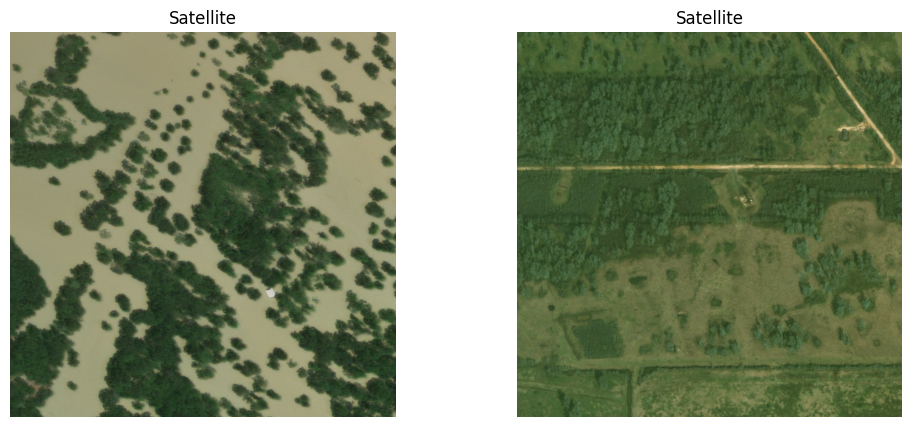

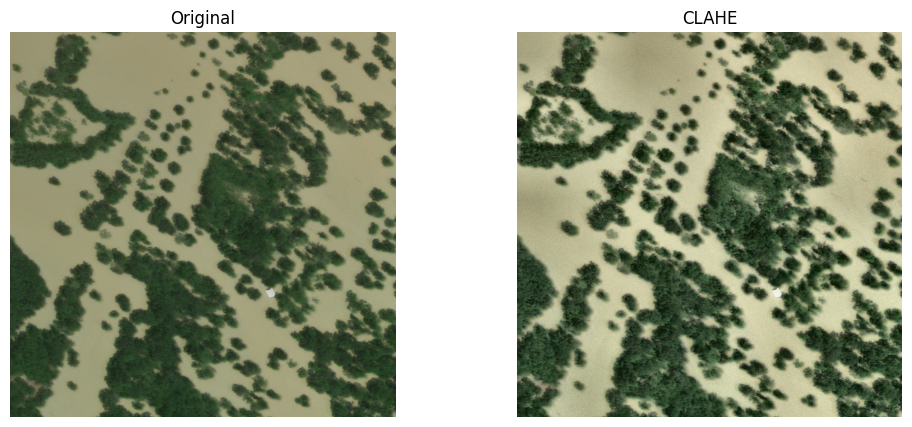

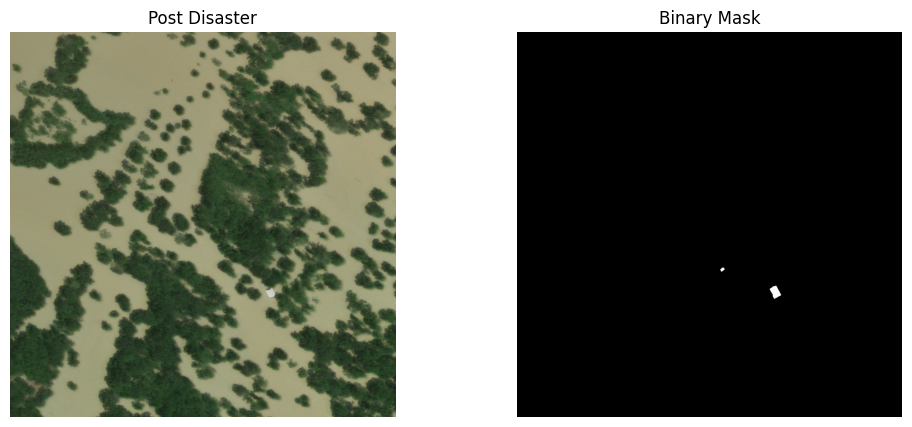

Pairs: 2799
Train: 2239
Validation: 560

===== EPOCH 1/10 =====


100%|██████████| 560/560 [08:33<00:00,  1.09it/s]



Loss : 0.6708
IoU  : 0.4853
F1   : 0.6436

✅ Best model saved

===== EPOCH 2/10 =====


100%|██████████| 560/560 [08:32<00:00,  1.09it/s]



Loss : 0.5042
IoU  : 0.5299
F1   : 0.6841

✅ Best model saved

===== EPOCH 3/10 =====


...


Loss : 0.3540
IoU  : 0.6154
F1   : 0.7563

✅ Best model saved

===== EPOCH 9/10 =====


100%|██████████| 560/560 [08:31<00:00,  1.10it/s]



Loss : 0.3454
IoU  : 0.6201
F1   : 0.7593

✅ Best model saved

===== EPOCH 10/10 =====


100%|██████████| 560/560 [08:26<00:00,  1.10it/s]



Loss : 0.3406
IoU  : 0.6200
F1   : 0.7587



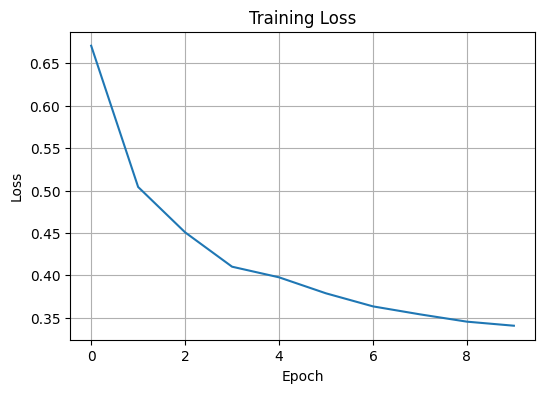

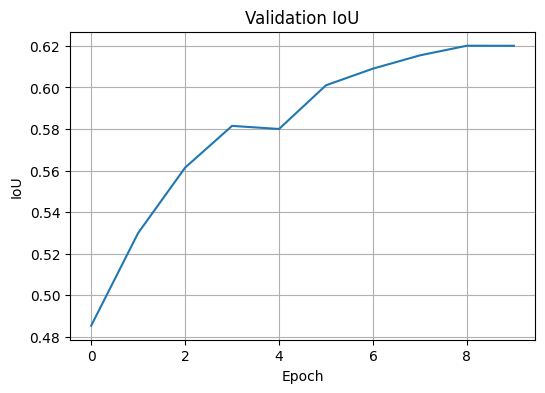

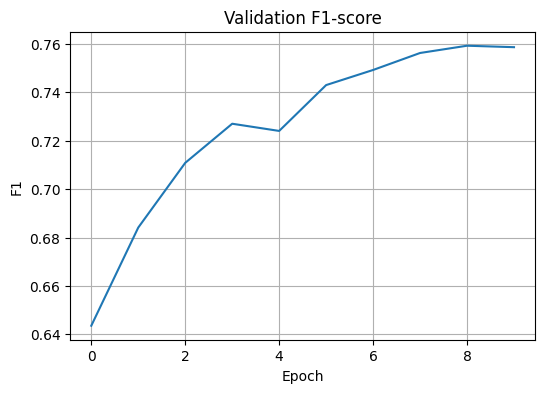

In [2]:
# =========================================================
# 🚀 XVIEW2 - SEGMENTATION BINAIRE (VERSION CORRIGÉE)
# =========================================================

!pip install segmentation-models-pytorch -q
!pip install albumentations -q
!pip install shapely -q

import os, json, cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from shapely.wkt import loads as wkt_loads

from sklearn.model_selection import train_test_split

# =========================================================
# DEVICE
# =========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# =========================================================
# PATH
# =========================================================
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

IMG_DIR = os.path.join(BASE, "train", "train", "images")
LBL_DIR = os.path.join(BASE, "train", "train", "labels")

print("Images:", len(os.listdir(IMG_DIR)))

# =========================================================
# VISUALISATION DATASET
# =========================================================
def show_samples():

    files = os.listdir(IMG_DIR)[:2]

    plt.figure(figsize=(12,5))

    for i,f in enumerate(files):

        img = np.array(Image.open(os.path.join(IMG_DIR,f)))

        plt.subplot(1,2,i+1)
        plt.imshow(img)
        plt.title("Satellite")
        plt.axis("off")

    plt.show()

show_samples()

# =========================================================
# CLAHE PREPROCESSING
# =========================================================
def clahe(img):

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    l,a,b = cv2.split(lab)

    clahe_filter = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe_filter.apply(l)

    merged = cv2.merge((l,a,b))

    return cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

# =========================================================
# VISUALISATION PREPROCESSING
# =========================================================
def show_preprocessing():

    file = os.listdir(IMG_DIR)[0]

    img = np.array(
        Image.open(
            os.path.join(IMG_DIR,file)
        ).convert("RGB")
    )

    processed = clahe(img)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(processed)
    plt.title("CLAHE")
    plt.axis("off")

    plt.show()

show_preprocessing()

# =========================================================
# MASK BINAIRE
# =========================================================
def mask_json(path):

    mask = np.zeros((1024,1024), dtype=np.uint8)

    with open(path) as f:
        data = json.load(f)

    for feature in data['features']['xy']:

        try:
            poly = wkt_loads(feature['wkt'])

            coords = np.array(
                poly.exterior.coords,
                np.int32
            )

            cv2.fillPoly(mask, [coords], 1)

        except:
            pass

    return mask

# =========================================================
# VISUALISATION MASK
# =========================================================
def show_mask():

    sample = os.listdir(IMG_DIR)

    post = [f for f in sample if "_post" in f][0]

    base = post.replace("_post_disaster.png","")

    img_path = os.path.join(
        IMG_DIR,
        base + "_post_disaster.png"
    )

    json_path = os.path.join(
        LBL_DIR,
        base + "_post_disaster.json"
    )

    img = np.array(Image.open(img_path).convert("RGB"))

    mask = mask_json(json_path)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Post Disaster")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask,cmap="gray")
    plt.title("Binary Mask")
    plt.axis("off")

    plt.show()

show_mask()

# =========================================================
# PAIRS
# =========================================================
files = os.listdir(IMG_DIR)

posts = [f for f in files if "_post" in f]

pairs = []

for f in posts:

    base = f.replace("_post_disaster.png","")

    pre = os.path.join(
        IMG_DIR,
        base + "_pre_disaster.png"
    )

    post = os.path.join(
        IMG_DIR,
        base + "_post_disaster.png"
    )

    lab = os.path.join(
        LBL_DIR,
        base + "_post_disaster.json"
    )

    if os.path.exists(pre):

        pairs.append({
            "pre": pre,
            "post": post,
            "label": lab
        })

print("Pairs:", len(pairs))

# =========================================================
# TRAIN / VALIDATION SPLIT
# =========================================================
train, val = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train))
print("Validation:", len(val))

# =========================================================
# AUGMENTATION
# =========================================================
IMG_SIZE = 512

train_tf = A.Compose([

    A.Resize(IMG_SIZE, IMG_SIZE),

    A.HorizontalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.Affine(
        scale=(0.9,1.1),
        p=0.5
    ),

    A.Normalize(),

    ToTensorV2()

])

val_tf = A.Compose([

    A.Resize(IMG_SIZE, IMG_SIZE),

    A.Normalize(),

    ToTensorV2()

])

# =========================================================
# DATASET
# =========================================================
class DS(Dataset):

    def __init__(self, pairs, tf):

        self.pairs = pairs
        self.tf = tf

    def __len__(self):

        return len(self.pairs)

    def __getitem__(self, i):

        p = self.pairs[i]

        pre = np.array(
            Image.open(p["pre"]).convert("RGB")
        )

        post = np.array(
            Image.open(p["post"]).convert("RGB")
        )

        # CLAHE
        pre = clahe(pre)
        post = clahe(post)

        # CONCAT 6 CHANNELS
        img = np.concatenate([pre, post], axis=2)

        # MASK
        mask = mask_json(p["label"])

        # AUGMENTATION
        out = self.tf(
            image=img,
            mask=mask
        )

        image = out["image"]

        mask = out["mask"].float().unsqueeze(0)

        return image, mask

# =========================================================
# DATALOADER
# =========================================================
train_ds = DS(train, train_tf)
val_ds = DS(val, val_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=4
)

# =========================================================
# MODEL
# =========================================================
model = smp.FPN(

    encoder_name="efficientnet-b4",

    encoder_weights="imagenet",

    in_channels=6,

    classes=1

).to(DEVICE)

# =========================================================
# LOSS
# =========================================================
dice_loss = smp.losses.DiceLoss(
    mode="binary"
)

bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):

    return (
        dice_loss(pred, target)
        +
        bce_loss(pred, target)
    )

# =========================================================
# OPTIMIZER
# =========================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

# =========================================================
# METRICS
# =========================================================
def metrics(pred, mask):

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

    TP = (pred * mask).sum()

    FP = (pred * (1-mask)).sum()

    FN = ((1-pred) * mask).sum()

    TN = ((1-pred) * (1-mask)).sum()

    iou = TP / (TP + FP + FN + 1e-6)

    dice_score = (
        2*TP / (2*TP + FP + FN + 1e-6)
    )

    precision = TP / (TP + FP + 1e-6)

    recall = TP / (TP + FN + 1e-6)

    f1 = (
        2 * precision * recall
        /
        (precision + recall + 1e-6)
    )

    acc = (
        (TP + TN)
        /
        (TP + FP + FN + TN + 1e-6)
    )

    return (
        iou.item(),
        dice_score.item(),
        f1.item(),
        acc.item()
    )

# =========================================================
# TRAINING
# =========================================================
losses = []

ious = []

f1s = []

best_iou = 0

EPOCHS = 10

for epoch in range(EPOCHS):

    print(f"\n===== EPOCH {epoch+1}/{EPOCHS} =====")

    # TRAIN
    model.train()

    total_loss = 0

    for x, y in tqdm(train_loader):

        x = x.to(DEVICE)

        y = y.to(DEVICE)

        optimizer.zero_grad()

        out = model(x)

        loss = loss_fn(out, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    # VALIDATION
    model.eval()

    iou_list = []

    f1_list = []

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)

            y = y.to(DEVICE)

            out = model(x)

            # ✅ CORRECTION ICI
            iou, dice_score, f1, acc = metrics(out, y)

            iou_list.append(iou)

            f1_list.append(f1)

    mean_loss = total_loss / len(train_loader)

    mean_iou = np.mean(iou_list)

    mean_f1 = np.mean(f1_list)

    losses.append(mean_loss)

    ious.append(mean_iou)

    f1s.append(mean_f1)

    print(f"""
Loss : {mean_loss:.4f}
IoU  : {mean_iou:.4f}
F1   : {mean_f1:.4f}
""")

    # SAVE BEST MODEL
    if mean_iou > best_iou:

        best_iou = mean_iou

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print("✅ Best model saved")

# =========================================================
# GRAPHS
# =========================================================
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(ious)
plt.title("Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(f1s)
plt.title("Validation F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.grid()
plt.show()

In [1]:
import os, json
from collections import Counter

LBL_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/labels"

# Chercher toutes les classes
classes = Counter()

files = [f for f in os.listdir(LBL_DIR) if "_post" in f]

for f in files[:500]:  # analyser 500 fichiers
    path = os.path.join(LBL_DIR, f)
    with open(path) as fp:
        data = json.load(fp)
    for feat in data['features']['xy']:
        subtype = feat['properties'].get('subtype', 'unknown')
        classes[subtype] += 1

print("=== CLASSES TROUVÉES ===")
for cls, count in classes.most_common():
    print(f"{cls} : {count} bâtiments")

=== CLASSES TROUVÉES ===
no-damage : 21471 bâtiments
destroyed : 3946 bâtiments
minor-damage : 3827 bâtiments
major-damage : 2572 bâtiments
un-classified : 598 bâtiments
